# Topic 3: RNN Network

This notebook builds, trains, and evaluates a Recurrent Neural Network using the **RNN** cell architecture to forecast airline passengers.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pickle
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 1. Load Flights Dataset

In [2]:
df = sns.load_dataset('flights')
print('Dataset head:')
print(df.head())
passengers = df['passengers'].values.astype('float32')
print('Total number of months:', len(passengers))

Dataset head:
   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121
Total number of months: 144


## 2. Preprocess and Scale Data

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(passengers.reshape(-1, 1)).flatten()

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler fit and saved as scaler.pkl')

Scaler fit and saved as scaler.pkl


## 3. Prepare Time Series Sequences

In [4]:
def create_sequences(data, seq_length=12):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 12
X, y = create_sequences(scaled_data, seq_length)
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (132, 12)
y shape: (132,)


## 4. Train-Test Split and Reshape

In [5]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Reshape for Keras recurrent layer: (samples, timesteps, features)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (105, 12, 1)
X_test shape: (27, 12, 1)


## 5. Build and Compile the RNN Model

In [6]:
model = models.Sequential([
    layers.Input(shape=(seq_length, 1)),
    layers.SimpleRNN(32, activation='tanh', return_sequences=False),
    layers.Dropout(0.1),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0240 - val_loss: 0.0538
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0065 - val_loss: 0.0175
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0059 - val_loss: 0.0112
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0063 - val_loss: 0.0234
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0057 - val_loss: 0.0237
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0068 - val_loss: 0.0049
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0034 - val_loss: 0.0082
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0028 - val_loss: 0.0170
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0029 - val_loss: 0.0102
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025 - val_loss: 0.0050
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030 - val_loss: 0.0109
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - val_

## 7. Evaluate and Save Model

In [8]:
loss = model.evaluate(X_test, y_test)
print(f'Test Loss (MSE): {loss:.6f}')
model.save('rnn_model.keras')
print('Model saved as rnn_model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0076
Test Loss (MSE): 0.007552
Model saved as rnn_model.keras


## 8. Visualize Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


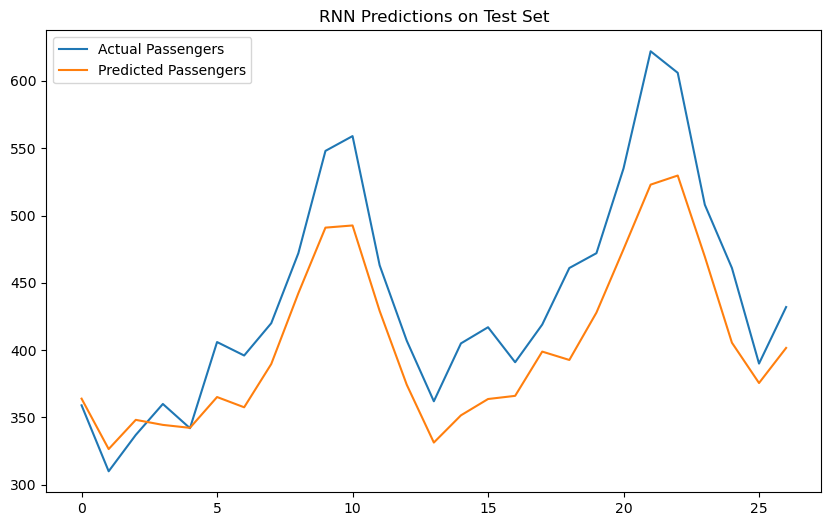

In [9]:
preds_scaled = model.predict(X_test)
preds = scaler.inverse_transform(preds_scaled)
actuals = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(10, 6))
plt.plot(actuals, label='Actual Passengers')
plt.plot(preds, label='Predicted Passengers')
plt.legend()
plt.title('RNN Predictions on Test Set')
plt.show()